## Dimensionality Reduction

In [1]:
from astroML.datasets import sdss_corrected_spectra
from astroML.utils import pickle_results

In [25]:
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)
print('Number of spectra: ' + str(len(spectra)))
print('Number of wavelength bins: ' + str(len(wavelengths)))

Number of spectra: 4000
Number of wavelength bins: 1000


In [67]:
import numpy as np

In [85]:
np.random.seed(500)
nrows = 4000 # We'll just look at 2000 random spectra
n_components = 8 # Do the fit with 5 components, which is the mean plus 4
ind = np.random.randint(spectra.shape[0], size=nrows)
spec_mean = spectra.mean(0) 

In [86]:
from sklearn.decomposition import PCA

In [87]:
pca = PCA(n_components - 1, svd_solver='randomized')
pca.fit(spectra[ind])
pca_comp = np.vstack([spec_mean, pca.components_]) # Add the mean to the components
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.8726668  0.06271941 0.03920273 0.00973775 0.00487652 0.00306689
 0.00213038]


In [88]:
import matplotlib.pyplot as plt

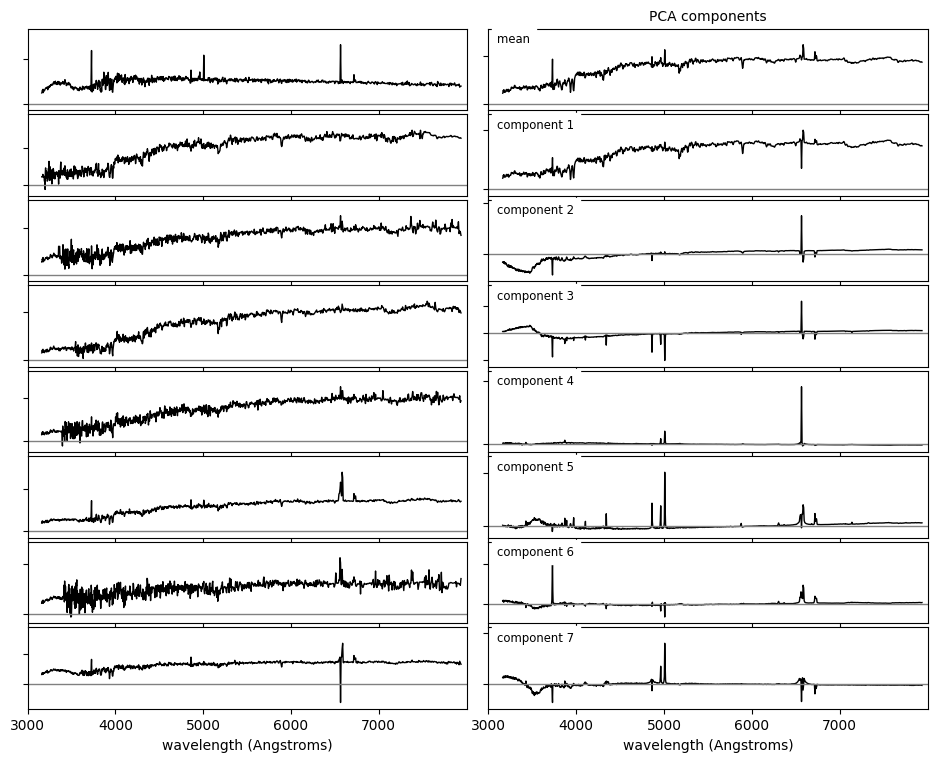

In [89]:
# Make plots
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

titles = 'PCA components'

for j in range(n_components):
    
    # plot the components
    ax = fig.add_subplot(n_components, 2, 2*j+2)
    ax.yaxis.set_major_formatter(plt.NullFormatter())
    ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
    
    if j < n_components - 1:
        ax.xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_xlabel('wavelength (Angstroms)')
    ax.plot(wavelengths, pca_comp[j], '-k', lw=1)

    # plot zero line
    xlim = [3000, 7999]
    ax.plot(xlim, [0, 0], '-', c='gray', lw=1)
    ax.set_xlim(xlim)

    # adjust y limits
    ylim = plt.ylim()
    dy = 0.05 * (ylim[1] - ylim[0])    
    ax.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)

    # plot the first j spectra
    ax2 = fig.add_subplot(n_components, 2, 2*j+1)
    ax2.yaxis.set_major_formatter(plt.NullFormatter())
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1000))
    if j < n_components - 1:
        ax2.xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax2.set_xlabel('wavelength (Angstroms)')
    ax2.plot(wavelengths, spectra[j], '-k', lw=1)
    
    # plot zero line
    ax2.plot(xlim, [0, 0], '-', c='gray', lw=1)
    ax2.set_xlim(xlim)

    if j == 0:
        ax.set_title(titles, fontsize='medium')
    if j == 0:
        label = 'mean'
    else:
        label = 'component %i' % j

    # adjust y limits
    ylim = plt.ylim()
    dy = 0.05 * (ylim[1] - ylim[0])    
    ax2.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)

    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            ha='left', va='top', bbox=dict(ec='w', fc='w'),
            fontsize='small')

plt.show()


In [90]:
for num_feats in np.arange(1,20, dtype = int):
    pca = PCA(n_components=num_feats)
    pca.fit(spectra[ind])
    if (sum(pca.explained_variance_ratio_)>0.995):
        break
print("{:d} features are needed to explain 99.5% of the variance".format(num_feats))

8 features are needed to explain 99.5% of the variance


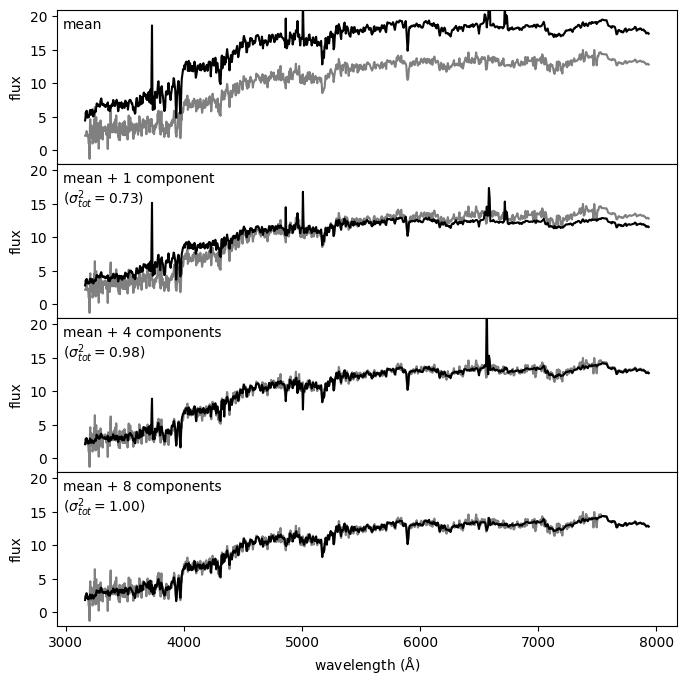

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from astroML.datasets import sdss_corrected_spectra

#------------------------------------------------------------
# Load the SDSS spectra
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

#------------------------------------------------------------
# Compute PCA with 8 components (explains ~95% of variance)
pca = PCA(n_components=8)
pca.fit(spectra)

# Explained variance
evals = pca.explained_variance_ratio_
evals_cs = np.cumsum(evals)

# Mean spectrum and PCA components
spec_mean = pca.mean_           # shape (1000,)
evecs = pca.components_         # shape (8, 1000)

#------------------------------------------------------------
# Choose one spectrum and project onto PCA space
spec = spectra[1]                               # shape (1000,)
coeff = np.dot(evecs, spec - spec_mean)         # shape (8,)

#------------------------------------------------------------
# Plot reconstruction with 0, 1, 4, and 8 components
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(hspace=0)

components_list = [0, 1, 4, 8]
for i, n in enumerate(components_list):
    ax = fig.add_subplot(4, 1, i + 1)
    
    # Original spectrum (in gray)
    ax.plot(wavelengths, spec, '-', c='gray', label='Original')
    
    # Reconstruction: mean + n components
    if n == 0:
        recon = spec_mean
    else:
        recon = spec_mean + np.dot(coeff[:n], evecs[:n])
    ax.plot(wavelengths, recon, '-k', label=f'Reconstruction ({n})')
    
    # Formatting
    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())
    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')
    
    # Text box
    if n == 0:
        text = "mean"
    elif n == 1:
        text = "mean + 1 component\n" + r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    else:
        text = f"mean + {n} components\n" + r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    ax.text(0.01, 0.95, text, ha='left', va='top', transform=ax.transAxes)

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()
